# **MÓDULO 20 - Projeto de Credit Score - Naive Bayes**


No módulo 17 vocês realizaram a primeira etapa do projeto de crédito de vocês.
Então fizeram o tratamendo dos dados, balancearam as classes, transformaram as variáveis categóricas e separam base de treino e teste.
Nessa aula aplicaremos o algoritmo de naive bayes a base de vocês afim de tentarmos trazer previsões do score de crédito.

**IMPORTANTE:** Não se esqueçam de ao enviar o código de vocês para os tutores, enviarem as bases, pois como cada um de vocês realizou as alterações de tratamento indidualmente o tutor precisa ter acesso aos seus dados individuais.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score
from sklearn.metrics import recall_score

Durante a aula nossa variável a ser prevista (churn) continha apenas 2 categorias, a base de vocês contém mais. O Naive Bayes pode ser aplicado para problemas de classificação com múltiplas classes da mesma forma que para problemas de classificação binária. O Naive Bayes é um algoritmo de classificação probabilístico que calcula a probabilidade de uma amostra pertencer a cada classe e seleciona a classe com a maior probabilidade como a previsão final.
Em resumo, o Naive Bayes pode ser aplicado da mesma maneira para problemas de classificação com múltiplas classes, e os mesmos princípios se aplicam em termos de treinamento, avaliação e aplicação do modelo.

# 1) Comece carregando as bases de treino (X e y) e teste (X e y).
Verifique se o número de linhas condiz, se as variáveis estão corretas sendo apenas a de score para y e as demais nas bases de X e por último, se Y está balanceada no teste.

In [5]:
#seu código aqui
X_test = pd.read_csv("X_test.csv", delimiter=',')
X_train = pd.read_csv("X_train_balanced.csv", delimiter=',')
y_test = pd.read_csv("y_test.csv", delimiter=',')
y_train = pd.read_csv("y_train_balanced.csv", delimiter=',')

In [6]:
print("Tamanho de X_train:", X_train.shape)

Tamanho de X_train: (252, 10)


In [7]:
print("Tamanho de X_test:", X_test.shape)

Tamanho de X_test: (41, 10)


In [8]:
print("Tamanho de y_train:", y_train.shape)

Tamanho de y_train: (252, 1)


In [9]:
print("Tamanho de y_test:", y_test.shape)

Tamanho de y_test: (41, 1)


In [12]:
y_test

,Credit_Score_encoded
0,0
1,1
2,0
3,1
4,1
5,0
6,1
7,1
8,1
9,1


In [13]:
X_test

,Age,Income,Number of Children,education_ordinal,Gender_Female,Gender_Male,Marital Status_Married,Marital Status_Single,Home Ownership_Owned,Home Ownership_Rented
0,25,55000.0,0,3,True,False,False,True,False,True
1,48,87500.0,1,5,True,False,True,False,True,False
2,26,55000.0,1,3,True,False,True,False,True,False
3,39,62500.0,2,3,True,False,True,False,True,False
4,35,90000.0,1,5,True,False,True,False,True,False
5,25,55000.0,0,3,True,False,False,True,False,True
6,48,82500.0,1,5,True,False,True,False,True,False
7,48,82500.0,1,5,True,False,True,False,True,False
8,36,95000.0,2,4,True,False,True,False,True,False
9,29,95000.0,1,1,True,False,True,False,True,False


In [14]:
y_train

,Credit_Score_encoded
0,0
1,2
2,0
3,0
4,0
...,...
247,2
248,2
249,2
250,2


In [15]:
X_train

,Age,Income,Number of Children,education_ordinal,Gender_Female,Gender_Male,Marital Status_Married,Marital Status_Single,Home Ownership_Owned,Home Ownership_Rented
0,26,45000.000000,0,2,True,False,False,True,False,True
1,29,27500.000000,0,1,True,False,False,True,False,True
2,25,62500.000000,0,3,True,False,False,True,False,True
3,29,68000.000000,2,5,True,False,True,False,True,False
4,31,65000.000000,0,3,False,True,False,True,False,True
...,...,...,...,...,...,...,...,...,...,...
247,27,36803.652916,0,1,True,False,False,True,False,True
248,27,37500.000000,0,1,True,False,False,True,False,True
249,28,29946.263487,0,1,True,False,False,True,False,True
250,27,35412.944984,0,1,True,False,False,True,False,True


In [16]:
# Contar o número de exemplos de cada classe em y_train
train_balance = y_train.value_counts()
print("Balanceamento em y_train:")
print(train_balance)

# Contar o número de exemplos de cada classe em y_test
test_balance = y_test.value_counts()
print("\nBalanceamento em y_test:")
print(test_balance)

Balanceamento em y_train:
Credit_Score_encoded
0                       84
1                       84
2                       84
Name: count, dtype: int64

Balanceamento em y_test:
Credit_Score_encoded
1                       29
0                        6
2                        6
Name: count, dtype: int64


# 2) Aplique o algoritmo de Naive Bayes aos dados de treinamento.

In [17]:
#seu código aqui
# Criação de uma instância do classificador Naive Bayes Gaussiano
naive_churn = GaussianNB()
# Treinamento do classificador usando os dados de treinamento
naive_churn.fit(X_train, y_train)

C:\Users\bruna\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,priors,None
,var_smoothing,1e-09


# 3) Faça a avaliação do modelo com os dados de treinamento.
Traga a acurácia, recall e plote a matriz de confusão. Não se esqueça de avaliar com suas palavras o desempenho do modelo, interpretando as métricas.

Dica: Para calcularmos o recall em classificação multi classe precisamos usar o atributo macro:
recall = recall_score(y_train, y_pred_train, average='macro')

In [18]:
#seu código aqui
# Fazer previsões para os dados de treino
y_pred_train = naive_churn.predict(X_train)
# Calcular a acurácia
accuracy = accuracy_score(y_train, y_pred_train)
print("Acurácia:", accuracy)

Acurácia: 0.9880952380952381


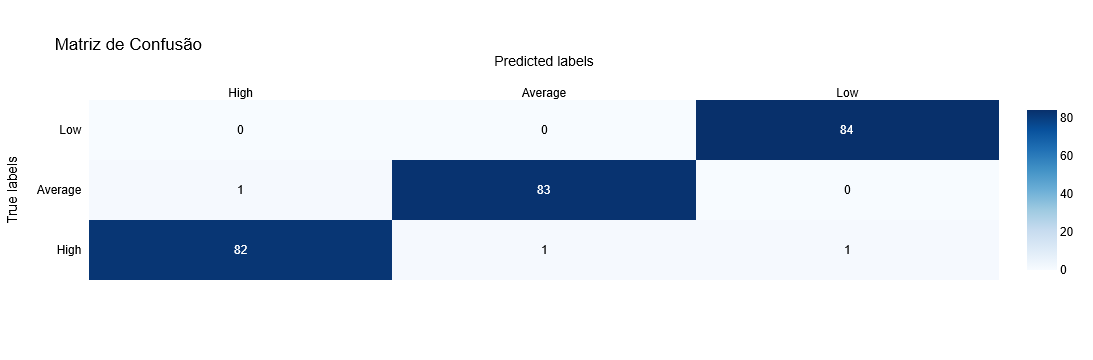

In [20]:
import plotly.figure_factory as ff
conf_matrix = confusion_matrix(y_train, y_pred_train)

# Definindo  nomes de classes
class_names = ['High', 'Average', 'Low']

# Plotando a matriz de confusão com Plotly
fig = ff.create_annotated_heatmap(
    z=conf_matrix,
    x=class_names,
    y=class_names,
    colorscale='Blues',
    showscale=True
)
fig.update_layout(
    title='Matriz de Confusão',
    xaxis_title='Predicted labels',
    yaxis_title='True labels',
    font=dict(
        family='Arial',
        size=12,
        color='black'
    )
)

In [22]:
recall = recall_score(y_train, y_pred_train,  average='macro')
print("Recall:", recall)

Recall: 0.9880952380952381


#### Pude verificar que o recall e a acuracia estão com a mesma proporção, indicando que o nivel de acerto dos positivos foram bem altos. Olhando a matriz de conbfusão visualizei somente três momentos em que o modelo fez a avaliação errada, mais da metade dos dados foram avaliados corretamente. Isso indica um alto desempenho do modelo na base de treino.

# 4) Aplique o modelo aos dados de teste e realize a avaliação dos resultados, da mesma forma que fez acima. Não se esqueça de avaliar com as suas palavras e comparar o desempenho da base treino com a teste.

In [23]:
#seu código aqui
y_pred_test = naive_churn.predict(X_test)

In [25]:
accuracy = accuracy_score(y_test, y_pred_test)
recall = recall_score(y_test, y_pred_test, average='macro')


print("Acurácia:", accuracy)
print("Recall:", recall)

Acurácia: 1.0
Recall: 1.0


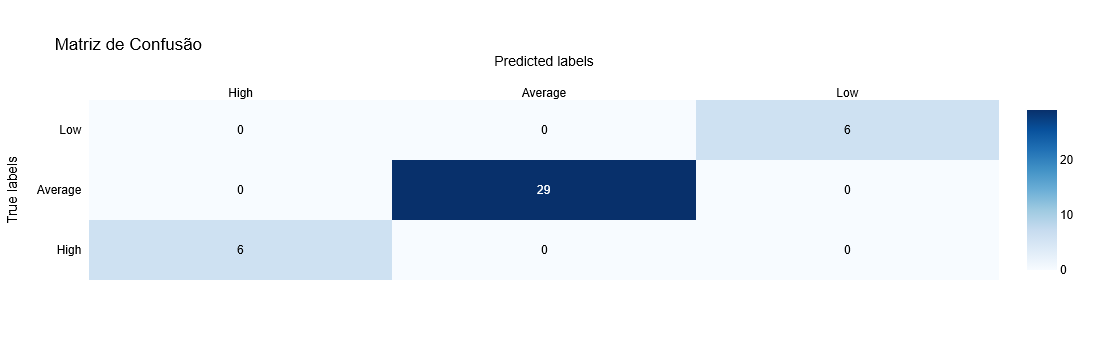

In [26]:
conf_matrix = confusion_matrix(y_test, y_pred_test)

# Definindo  nomes de classes
class_names = ['High', 'Average', 'Low']

# Plotando a matriz de confusão com Plotly
fig = ff.create_annotated_heatmap(
    z=conf_matrix,
    x=class_names,
    y=class_names,
    colorscale='Blues',
    showscale=True
)
fig.update_layout(
    title='Matriz de Confusão',
    xaxis_title='Predicted labels',
    yaxis_title='True labels',
    font=dict(
        family='Arial',
        size=12,
        color='black'
    )
)

#### Na base de teste o modelo teve um desempenho melhor do que no treinamento, chegando a 100% de acuracia e recall. Na matriz de confusão não vemos nenhum registro classificado errado. Como na base de treino já tivemos um desempenho de 98% de acuracia e de recall, não está tão distânte a marca de 100% que tivemos na base de teste.

# 5) Descreva com suas palavras o projeto desenvolvido nessa atividade e qual o nosso objetivo principal ao aplicarmos o algoritmo de naive bayes a base de crédito.
Utilize pelo menos 4 linhas.

Dica: Caso você ainda esteja tendo dificuldade em visualizar a aplicação dos projetos e objetivo, consulte seus tutores!

#### Esse projeto teve como objetivo a criação de um modelo que pudessemos realizar a previsão de credit score. A primeira etapa foi a limpeza e tratamento dos dados, para verificar quais dados eram faltantes, analisar a correlação entre eles e o balanceamento. Após foi feito o ajuste nas variáveis de texto e feito a separação dos dados para a aplicação de um modelo supervisionado. Após ter sido feita a separação dos dados, foi aplicado o balanceamento na base treino, para que o modelo pudesse aprender sem vies. A segunda etapa consistia em verificar as bases separadas e balanceadas e aplicar o modelo de naive bayes, que leva em conta que todas as variáveis são independentes. Embora na etapa um termos verificado variaveis com correlação de 0.63(aproximadamente, não lembro com exatidão), o modelo de naive bayes se adequou muito bem ao conjunto de dados, conseguindo prever muito bem o score de crédito através da probabilidade. 